# Even/odd functions and integration by parts -- for a computer-engineering researcher

Two workhorse tools of mathematical physics, each with a sharp engineering payoff:

- **Parity (even/odd).** $f(-x)=f(x)$ (even) or $f(-x)=-f(x)$ (odd). Over a symmetric interval an **odd
  integrand vanishes**, $\int_{-a}^{a}f_{\text{odd}}=0$, and an even one halves to $2\int_0^a$. This is not
  just labor-saving on paper -- it is why a real, even signal has a **real spectrum**, the basis of the
  **DCT** and the real-input FFT that halve computation and storage.
- **Integration by parts.** $\int u\,dv=uv-\int v\,du$ moves a derivative from one factor onto the other.
  In physics it gives kinetic energy $\langle T\rangle=\frac{\hbar^2}{2m}\int|\psi'|^2$ and proves the
  momentum operator is Hermitian. For an engineer it is the **adjoint (transpose) of differentiation** --
  discrete summation by parts is $D^\top=-D$, and *that transpose is exactly what backpropagation
  computes* when a gradient flows back through a derivative.

Everything is derived and `assert`ed in **SymPy** (`init_printing`), checked numerically in **Torch**
(FFT parity, the discrete adjoint), and summarized in **Pandas**. Python 3.12 + Torch kernel.

In [1]:
import sympy as sp
import numpy as np, torch, pandas as pd
import matplotlib.pyplot as plt
sp.init_printing()
torch.set_default_dtype(torch.float64)
x, a = sp.symbols('x a', real=True); a = sp.symbols('a', positive=True)
print("sympy", sp.__version__, "| torch", torch.__version__, "| pandas", pd.__version__)

sympy 1.14.0 | torch 2.11.0+cu128 | pandas 2.3.3


## Parity: products, symmetric integrals, and the even/odd decomposition

Products follow a sign rule: even$\times$even = even, odd$\times$odd = even, even$\times$odd = odd. Any
function splits into an even and an odd part, $f(x)=\tfrac12[f(x)+f(-x)]+\tfrac12[f(x)-f(-x)]$ -- for the
exponential this is $e^x=\cosh x+\sinh x$. Over $[-a,a]$ the odd part integrates to zero.

In [2]:
even_rep, odd_rep = x**2, x**3                          # representative even / odd functions
flip = lambda f: f.subs(x, -x)
assert sp.simplify(flip(even_rep) - even_rep) == 0 and sp.simplify(flip(odd_rep) + odd_rep) == 0
assert sp.simplify(flip(even_rep*odd_rep) + even_rep*odd_rep) == 0    # even*odd is odd

# symmetric-interval integrals: odd -> 0, even -> 2 * half-integral
assert sp.integrate(odd_rep, (x, -a, a)) == 0
assert sp.integrate(even_rep, (x, -a, a)) == 2*sp.integrate(even_rep, (x, 0, a))
print("odd integral over [-a,a] =", sp.integrate(odd_rep, (x, -a, a)))
print("even integral over [-a,a] =", sp.integrate(even_rep, (x, -a, a)), "= 2 * int_0^a")

# even/odd decomposition of exp(x)
f = sp.exp(x)
f_even = sp.simplify((f + flip(f))/2); f_odd = sp.simplify((f - flip(f))/2)
assert f_even == sp.cosh(x) and f_odd == sp.sinh(x)
print("exp(x) = ", f_even, "+", f_odd, "  (even cosh + odd sinh)")

odd integral over [-a,a] = 0
even integral over [-a,a] = 2*a**3/3 = 2 * int_0^a
exp(x) =  cosh(x) + sinh(x)   (even cosh + odd sinh)


## Parity in Fourier analysis, and the real-FFT payoff (Torch)

An **even** function has a pure **cosine** series (all $b_n=0$); an **odd** function has a pure **sine**
series (all $a_n=0$) -- because the discarded coefficients have odd integrands. The same fact in the
transform domain: a real, even signal has a **real** DFT, and a real, odd signal has a purely **imaginary**
DFT. Torch confirms it; this is exactly why the **DCT** and real-input FFT exist -- half the arithmetic and
half the storage.

In [3]:
# SymPy: even x^2 kills all sine coefficients; odd x kills all cosine coefficients (on [-pi,pi])
for nn in (1, 2, 3):
    b_n = sp.integrate(x**2*sp.sin(nn*x), (x, -sp.pi, sp.pi))       # sine coeff of an even function
    a_n = sp.integrate(x*sp.cos(nn*x),   (x, -sp.pi, sp.pi))        # cosine coeff of an odd function
    assert b_n == 0 and a_n == 0
print("even function: all b_n = 0 (cosine series);  odd function: all a_n = 0 (sine series)")

# Torch: real even signal -> real spectrum;  real odd signal -> imaginary spectrum
N = 64; n = torch.arange(N)
even_sig = torch.cos(2*torch.pi*3*n/N)                              # even about 0 (circularly)
odd_sig  = torch.sin(2*torch.pi*3*n/N)                              # odd about 0
Fe, Fo = torch.fft.fft(even_sig), torch.fft.fft(odd_sig)
print(f"even signal: max |Im(FFT)| = {float(Fe.imag.abs().max()):.2e}  -> spectrum is REAL (DCT)")
print(f"odd  signal: max |Re(FFT)| = {float(Fo.real.abs().max()):.2e}  -> spectrum is IMAGINARY (DST)")
assert Fe.imag.abs().max() < 1e-9 and Fo.real.abs().max() < 1e-9

even function: all b_n = 0 (cosine series);  odd function: all a_n = 0 (sine series)
even signal: max |Im(FFT)| = 1.24e-14  -> spectrum is REAL (DCT)
odd  signal: max |Re(FFT)| = 1.24e-14  -> spectrum is IMAGINARY (DST)


## Physics: parity is a selection rule

For a symmetric potential the stationary states have definite parity, so $|\psi|^2$ is even and
$\langle x\rangle=\int x|\psi|^2\,dx=0$ (odd integrand) -- the expectation of position vanishes without any
work. The same argument gives dipole **selection rules**: $\langle m|x|n\rangle=0$ unless the states have
*opposite* parity. For the harmonic oscillator, $\langle0|x|2\rangle=0$ (both even) but
$\langle0|x|1\rangle\neq0$ (opposite parity) -- only parity-changing transitions radiate.

In [4]:
psi = lambda k: sp.hermite(k, x)*sp.exp(-x**2/2)                # HO eigenstate (unnormalized)
mean_x0 = sp.integrate(x*psi(0)**2, (x, -sp.oo, sp.oo))            # <x> in the ground state
m02 = sp.integrate(psi(0)*x*psi(2), (x, -sp.oo, sp.oo))            # even * x * even -> odd -> 0
m01 = sp.integrate(psi(0)*x*psi(1), (x, -sp.oo, sp.oo))            # even * x * odd  -> even -> nonzero
assert mean_x0 == 0 and m02 == 0 and m01 != 0
print("<x>_0 =", mean_x0, "  <0|x|2> =", m02, "(forbidden)  <0|x|1> =", sp.simplify(m01), "(allowed)")

<x>_0 = 0   <0|x|2> = 0 (forbidden)  <0|x|1> = sqrt(pi) (allowed)


## Integration by parts: kinetic energy and a Hermitian momentum

$\int u\,dv=uv-\int v\,du$. Its two signature uses in quantum mechanics:

1. **Kinetic energy.** $\langle T\rangle=-\dfrac{\hbar^2}{2m}\displaystyle\int\psi\,\psi''\,dx
   =\dfrac{\hbar^2}{2m}\int(\psi')^2\,dx$ once the boundary term $[\psi\psi']$ vanishes (fields decay) --
   manifestly positive.
2. **Hermiticity of $\hat p=-i\hbar\,d/dx$.** IBP shows $d/dx$ is *anti*-symmetric,
   $\int(\psi\varphi'+\psi'\varphi)\,dx=[\psi\varphi]=0$, so $-i\,d/dx$ is symmetric (Hermitian) -- its
   eigenvalues (momenta) are real.

In [5]:
psi_g = sp.exp(-x**2/2)                                        # a decaying test state (hbar=m=1)
T_curv = -sp.Rational(1,2)*sp.integrate(psi_g*sp.diff(psi_g, x, 2), (x, -sp.oo, sp.oo))
T_grad =  sp.Rational(1,2)*sp.integrate(sp.diff(psi_g, x)**2,       (x, -sp.oo, sp.oo))
assert sp.simplify(T_curv - T_grad) == 0                          # IBP: -1/2 int psi psi'' = 1/2 int (psi')^2
print("kinetic energy:  -1/2 int psi psi'' =", T_curv, "  =  1/2 int (psi')^2 =", T_grad)

# d/dx is anti-symmetric (boundary term vanishes for decaying states) -> -i d/dx is Hermitian
phi_g = sp.exp(-(x-1)**2/2)
antisym = sp.simplify(sp.integrate(psi_g*sp.diff(phi_g, x) + sp.diff(psi_g, x)*phi_g, (x, -sp.oo, sp.oo)))
assert antisym == 0
print("int (psi phi' + psi' phi) dx =", antisym, "  -> d/dx anti-symmetric -> p = -i d/dx is Hermitian")

# a textbook IBP evaluation for good measure
ibp_demo = sp.integrate(x*sp.exp(x), (x, 0, 1))
print("int_0^1 x e^x dx =", ibp_demo, " (by parts: [x e^x] - int e^x = 1)")
assert ibp_demo == 1

kinetic energy:  -1/2 int psi psi'' = sqrt(pi)/4   =  1/2 int (psi')^2 = sqrt(pi)/4


int (psi phi' + psi' phi) dx = 0   -> d/dx anti-symmetric -> p = -i d/dx is Hermitian
int_0^1 x e^x dx = 1  (by parts: [x e^x] - int e^x = 1)


## The engineering punchline: integration by parts is the adjoint (transpose)

Discretize the derivative as a matrix $D$. **Summation by parts** -- the discrete IBP -- says
$(D\psi)\!\cdot\!\varphi=-\psi\!\cdot\!(D\varphi)$ for fields vanishing at the boundary, i.e. the adjoint of
the derivative is $D^\top=-D$ (a central-difference $D$ is exactly skew-symmetric). This *transpose* is the
heart of the **adjoint method** and of **backpropagation**: when a gradient flows backward through a layer
that applied $D$, it is multiplied by $D^\top$. IBP and the chain-rule-in-reverse are the same operation --
so the phase-retrieval gradients earlier in this project are integration by parts in disguise.

In [6]:
N = 64; h = 1.0/(N + 1)
D = torch.zeros(N, N)
i = torch.arange(N - 1)
D[i, i + 1] = 1/(2*h); D[i + 1, i] = -1/(2*h)                     # central-difference derivative
print("adjoint of the derivative D^T == -D :", torch.allclose(D, -D.T))
assert torch.allclose(D, -D.T)                                    # skew-symmetric: adjoint = minus itself

torch.manual_seed(0)
psi_v, phi_v = torch.rand(N), torch.rand(N)                       # implicitly zero outside (Dirichlet)
lhs = (D @ psi_v) @ phi_v                                         # (D psi) . phi
rhs = -(psi_v @ (D @ phi_v))                                      # - psi . (D phi)
print(f"summation by parts:  (D psi).phi = {float(lhs):+.4f}   -psi.(D phi) = {float(rhs):+.4f}")
assert torch.allclose(lhs, rhs)                                   # discrete integration by parts
print("=> IBP is the transpose D^T; backprop through a derivative layer multiplies by exactly this")

adjoint of the derivative D^T == -D : True
summation by parts:  (D psi).phi = +22.1568   -psi.(D phi) = +22.1568
=> IBP is the transpose D^T; backprop through a derivative layer multiplies by exactly this


## Pandas summary

In [7]:
rows = [
    {"tool": "odd integral on [-a,a]",     "result": "0",           "engineering use": "skip half the work"},
    {"tool": "even integral on [-a,a]",    "result": "2*int_0^a",   "engineering use": "fold the domain"},
    {"tool": "even signal -> real FFT",    "result": "Im=0",        "engineering use": "DCT / real-FFT (2x faster)"},
    {"tool": "odd signal -> imag FFT",     "result": "Re=0",        "engineering use": "DST"},
    {"tool": "<0|x|2> (same parity)",      "result": "0",           "engineering use": "selection rule (no transition)"},
    {"tool": "<0|x|1> (opposite parity)",  "result": "nonzero",     "engineering use": "allowed transition"},
    {"tool": "kinetic energy IBP",         "result": "1/2 int(psi')^2", "engineering use": "positive-definite form"},
    {"tool": "discrete IBP  D^T = -D",     "result": "adjoint",     "engineering use": "backprop / adjoint method"},
]
df = pd.DataFrame(rows)
print(df.to_string(index=False))

                     tool          result                engineering use
   odd integral on [-a,a]               0             skip half the work
  even integral on [-a,a]       2*int_0^a                fold the domain
  even signal -> real FFT            Im=0     DCT / real-FFT (2x faster)
   odd signal -> imag FFT            Re=0                            DST
    <0|x|2> (same parity)               0 selection rule (no transition)
<0|x|1> (opposite parity)         nonzero             allowed transition
       kinetic energy IBP 1/2 int(psi')^2         positive-definite form
   discrete IBP  D^T = -D         adjoint      backprop / adjoint method


## Plots

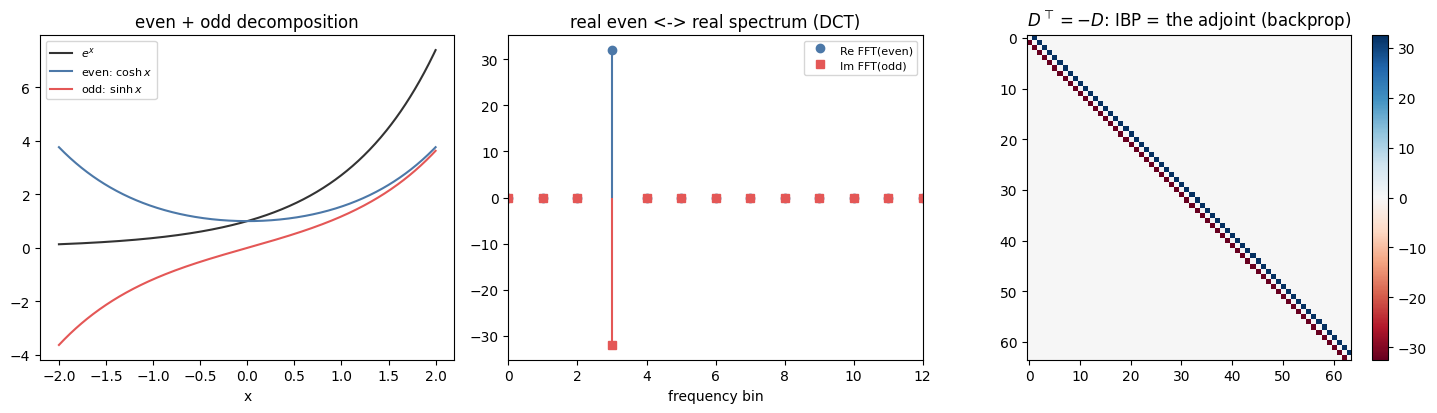

In [8]:
fig, ax = plt.subplots(1, 3, figsize=(14.5, 4.2))
# (1) even/odd decomposition of exp(x)
xg = np.linspace(-2, 2, 400)
ax[0].plot(xg, np.exp(xg), color="#333", label="$e^x$")
ax[0].plot(xg, np.cosh(xg), color="#4C78A8", label="even: $\\cosh x$")
ax[0].plot(xg, np.sinh(xg), color="#E45756", label="odd: $\\sinh x$")
ax[0].set_title("even + odd decomposition"); ax[0].legend(fontsize=8); ax[0].set_xlabel("x")
# (2) FFT parity: even signal -> real spectrum, odd signal -> imaginary spectrum
ax[1].stem(np.arange(N), Fe.real.numpy(), linefmt="#4C78A8", markerfmt="o", basefmt=" ", label="Re FFT(even)")
ax[1].stem(np.arange(N), Fo.imag.numpy(), linefmt="#E45756", markerfmt="s", basefmt=" ", label="Im FFT(odd)")
ax[1].set_xlim(0, 12); ax[1].set_title("real even <-> real spectrum (DCT)"); ax[1].legend(fontsize=8)
ax[1].set_xlabel("frequency bin")
# (3) the derivative matrix is skew-symmetric: D^T = -D (the discrete adjoint)
im = ax[2].imshow(D.numpy(), cmap="RdBu", vmin=-abs(D).max().item(), vmax=abs(D).max().item())
ax[2].set_title("$D^\\top=-D$: IBP = the adjoint (backprop)"); fig.colorbar(im, ax=ax[2], fraction=0.046)
plt.tight_layout(); plt.show()

## What to write down

- **Parity kills integrals**: $\int_{-a}^{a}f_{\text{odd}}=0$, $\int_{-a}^{a}f_{\text{even}}=2\int_0^a$.
  Products: even$\times$odd = odd. Every function $=$ even part $+$ odd part.
- **Parity is a selection rule**: $\langle x\rangle=0$ for symmetric states; $\langle m|x|n\rangle=0$ unless
  parities differ. Even functions are cosine/real in Fourier space; odd are sine/imaginary -- the reason the
  **DCT and real-FFT** exist and run at half cost.
- **Integration by parts** moves the derivative: $\int u\,dv=uv-\int v\,du$. It makes kinetic energy
  $\frac{\hbar^2}{2m}\int(\psi')^2$ (positive) and $\hat p$ Hermitian (real momenta).
- **The engineer's version**: discrete IBP is $D^\top=-D$ -- the **adjoint/transpose of differentiation**,
  which is exactly what **backpropagation** applies when a gradient flows back through a derivative. Symmetry
  halves the compute; IBP is the reverse-mode chain rule.

Subject-verb-object: parity annihilates the odd integrand; the cosine series survives; by parts moves the
derivative; the transpose carries the gradient back.